In [19]:
# step 1 import the necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# data set 
from sklearn.datasets import load_iris
# data standardization
from sklearn.preprocessing import StandardScaler
# PCA
from sklearn.decomposition import PCA

In [20]:
# step 2 load and prepare the data
# load the iris data set
iris = load_iris()
x = iris.data
y = iris.target

features = iris.feature_names

df = pd.DataFrame(x, columns=features)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [21]:
# step 3 Standardize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [22]:
# step 4 Apply PCA
pca = PCA(n_components=2) # n_components is the number of principal components we want to keep
x_pca = pca.fit_transform(x_scaled)

In [23]:
# step 5 check the explained variance ratio
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
# total variance explained by the two principal components
print(f"Total variance explained: {np.sum(pca.explained_variance_ratio_)}")

Explained variance ratio: [0.72962445 0.22850762]
Total variance explained: 0.9581320720000164


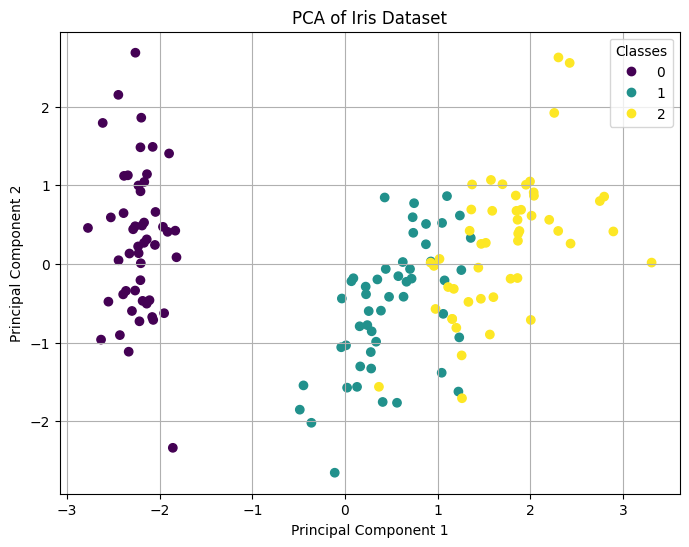

In [24]:
# step 6 visualize the results
plt.figure(figsize=(8,6))
scatter = plt.scatter(x_pca[:,0], # first principal component
                        x_pca[:,1], # second principal component
                        c=y, # color by target
                        cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend(*scatter.legend_elements(), title="Classes")
plt.grid()
plt.show()

In [25]:
# pca custom n_components
pca_custom = PCA(n_components=0.95) # keep enough components to explain 95% of the variance
x_pca_custom = pca_custom.fit_transform(x_scaled)
print(f"Number of components to explain 95% variance: {pca_custom.n_components_}")

Number of components to explain 95% variance: 2
